In [53]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from keras import backend as K
from keras.models import Sequential
from keras.layers import Input, Conv2D, Activation, MaxPooling2D, Flatten, Dense, Lambda, Dropout
from keras.optimizers import RMSprop
import re

# Constants
IMAGE_SIZE = 64
RESIZE = False
#TOTAL_SAMPLE_SIZE = 25000  # range: 5000-50000
#CHANNELS = 3
FOLDER_COUNT = 2
IMAGE_COUNT = 40  # range: 0-50
BATCH_SIZE = 64
normal_folder_path = 'C:\\Users\\SS IT\\Desktop\\Toward Ransomware Detection Using Few-shot learning\\RanSapDatasetand_Image\\Images\\Normal'
attack_folder_path = 'C:\\Users\\SS IT\\Desktop\\Toward Ransomware Detection Using Few-shot learning\\RanSapDatasetand_Image\Images\\ransomware'
total_sample_size =   80# sumation of both benign and attack dataset



def read_image(filename, byteorder='>'):
    """
    Read a raw PGM image file and return a numpy array representation.
    """
    with open(filename, 'rb') as f:
        buffer = f.read()

    header, width, height, maxval = re.search(
        b"(^P5\s(?:\s*#.*[\r\n])*"
        b"(\d+)\s(?:\s*#.*[\r\n])*"
        b"(\d+)\s(?:\s*#.*[\r\n])*"
        b"(\d+)\s(?:\s*#.*[\r\n]\s)*)", buffer).groups()

    return np.frombuffer(buffer, dtype='u1' if int(maxval) < 256 else byteorder+'u2',
                         count=int(width)*int(height),
                         offset=len(header)).reshape((int(height), int(width)))

def euclidean_distance(vects):
    x, y = vects
    return K.sqrt(K.sum(K.square(x - y), axis=1, keepdims=True))

def eucl_dist_output_shape(shapes):
    shape1, _ = shapes
    return (shape1[0], 1)

def contrastive_loss(y_true, y_pred):
    margin = 1
    square_pred = K.square(y_pred)
    margin_square = K.square(K.maximum(margin - y_pred, 0))
    return K.mean(y_true * square_pred + (1 - y_true) * margin_square)

def compute_accuracy(predictions, labels):
    return labels[predictions.ravel() < 0.5].mean()

def accuracy(y_true, y_pred):
    return K.mean(K.equal(y_true, K.cast(y_pred < 0.5, y_true.dtype)))



In [54]:
import os
import numpy as np
import matplotlib.image as mpimg
from scipy.ndimage import zoom
def get_data(folder_normal, folder_attack, total_sample_size):
    """
    Load images from specified folders and prepare them as pairs for the Siamese network.
    
    :param folder_normal: Path to the folder containing normal images.
    :param folder_attack: Path to the folder containing attack images.
    :param total_sample_size: Number of pairs to generate.
    :return: Pair of images and their labels.
    """
    # Get the list of image file names
    normal_images = os.listdir(folder_normal)
    attack_images = os.listdir(folder_attack)

    # Calculate the total number of images in each folder
    num_normal_images = len(normal_images)
    num_attack_images = len(attack_images)

    # Initialize arrays for storing image pairs and labels
    pairs = np.zeros([total_sample_size, 2, 64, 64, 1])
    labels = np.zeros([total_sample_size, 1])

    for i in range(total_sample_size):
        # Select a random pair of normal images for half the pairs
        if i % 2 == 0:
            idx1, idx2 = np.random.choice(num_normal_images, 2, replace=False)
            img1 = mpimg.imread(os.path.join(folder_normal, normal_images[idx1]), 'rw+')
            img2 = mpimg.imread(os.path.join(folder_normal, normal_images[idx2]), 'rw+')
            labels[i] = 0
        # Select a random pair of attack images for the other half
        else:
            idx1, idx2 = np.random.choice(num_attack_images, 2, replace=False)
            img1 = mpimg.imread(os.path.join(folder_attack, attack_images[idx1]), 'rw+')
            img2 = mpimg.imread(os.path.join(folder_attack, attack_images[idx2]), 'rw+')
            labels[i] = 1

        # Convert images to grayscale and resize if necessary
        img1_gray = np.dot(img1[..., :3], [0.2989, 0.5870, 0.1140])
        img2_gray = np.dot(img2[..., :3], [0.2989, 0.5870, 0.1140])

       
        pairs[i, 0, :, :, 0] = img1_gray
        pairs[i, 1, :, :, 0] = img2_gray

    return pairs, labels
    
X, Y = get_data(normal_folder_path, attack_folder_path, total_sample_size)

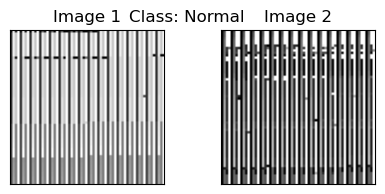

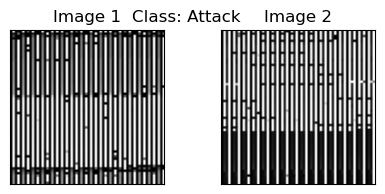

In [55]:
import matplotlib.pyplot as plt

def plot_images(pairs, labels, index):
    """
    Plots a pair of images either from the 'normal' or 'attack' class.

    :param pairs: Array of image pairs.
    :param labels: Array of labels corresponding to the image pairs.
    :param index: Index of the pair to be plotted.
    """
    plt.figure(figsize=(5, 2))

    # Plot the first image in the pair
    plt.subplot(1, 2, 1)
    plt.imshow(pairs[index, 0].reshape(64, 64), cmap='gray')
    plt.xticks([])
    plt.yticks([])
    plt.title("Image 1")

    # Plot the second image in the pair
    plt.subplot(1, 2, 2)
    plt.imshow(pairs[index, 1].reshape(64, 64), cmap='gray')
    plt.xticks([])
    plt.yticks([])
    plt.title("Image 2")

    plt.suptitle("Class: " + ("Normal" if labels[index] == 0 else "Attack"))
    plt.show()

# Plot one pair from the 'normal' class
normal_indices = [i for i, label in enumerate(Y) if label == 0]
plot_images(X, Y, normal_indices[0])

# Plot one pair from the 'attack' class
attack_indices = [i for i, label in enumerate(Y) if label == 1]
plot_images(X, Y, attack_indices[0])


In [56]:
unique, counts = np.unique(Y, return_counts=True)
print("Label counts:", dict(zip(unique, counts)))


Label counts: {0.0: 40, 1.0: 40}


In [57]:

def build_base_network(input_shape):
    """
    Create the base network for the Siamese architecture.
    """
    model = Sequential()
    filters = [16, 32, 16]
    kernel_size = 3

    # Convolutional Layer 1
    model.add(Conv2D(filters[0], (kernel_size, kernel_size), padding='valid', input_shape=input_shape))
    model.add(Activation('relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # Convolutional Layer 2
    model.add(Conv2D(filters[1], (kernel_size, kernel_size), padding='valid'))
    model.add(Activation('relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # Convolutional Layer 3
    model.add(Conv2D(filters[2], (kernel_size, kernel_size), padding='valid'))
    model.add(Activation('relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # Flatten and Dense Layers
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dense(50, activation='relu'))

    return model


In [58]:

from keras.models import Model
from keras.optimizers import Adam

# Prepare the input dimensions from the dataset
input_dim = (64, 64, 1)

# Create the base network
base_network = build_base_network(input_dim)

# Create the input layers
input_a = Input(shape=input_dim)
input_b = Input(shape=input_dim)

# Because we re-use the same instance `base_network`,
# the weights of the network will be shared across the two branches
processed_a = base_network(input_a)
processed_b = base_network(input_b)


# Concatenate the embeddings from both arms


In [59]:
def compute_embeddings(model, images):
    """
    Compute the embeddings for a set of images using the base network of a Siamese model.

    :param model: The base network of the Siamese model.
    :param images: A numpy array of images for which to compute embeddings.
    :return: Embeddings of the input images.
    """
    # Ensure the images are in the correct shape (number of images, height, width, channels)
    images = np.expand_dims(images, axis=-1) if images.ndim == 3 else images

    # Compute embeddings
    embeddings = model.predict(images)

    return embeddings

In [60]:
def compute_concatenated_embeddings(model, images_a, images_b):
    """
    Compute concatenated embeddings for pairs of images using the base network of a Siamese model.

    :param model: The base network of the Siamese model.
    :param images_a: A numpy array of the first images in each pair.
    :param images_b: A numpy array of the second images in each pair.
    :return: Concatenated embeddings of the image pairs.
    """
    # Ensure the images are in the correct shape
    images_a = np.expand_dims(images_a, axis=-1) if images_a.ndim == 3 else images_a
    images_b = np.expand_dims(images_b, axis=-1) if images_b.ndim == 3 else images_b

    # Compute embeddings for each set of images
    embeddings_a = model.predict(images_a)
    embeddings_b = model.predict(images_b)

    # Concatenate the embeddings
    concatenated_embeddings = np.concatenate([embeddings_a, embeddings_b], axis=-1)

    return concatenated_embeddings, embeddings_a, embeddings_b
    
concatenated_embeddings, embeddings_a, embeddings_b = compute_concatenated_embeddings(base_network,X[:, 0], X[:, 1])


3/3 [==============================] - 0s 5ms/step


3/3 [==============================] - 0s 8ms/step


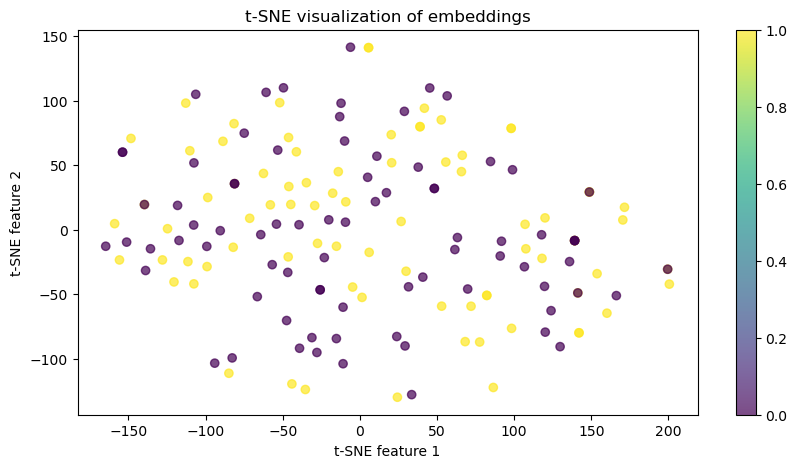

In [61]:
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import tensorflow as tf

def compute_embeddings(model, images):
    images = np.expand_dims(images, axis=-1) if images.ndim == 3 else images
    return model.predict(images)

# Assuming base_network is your Siamese model's base network
# and X[:, 0] and X[:, 1] are your image pairs
embeddings_a = compute_embeddings(base_network, X[:, 0])
embeddings_b = compute_embeddings(base_network, X[:, 1])

# Now, let's use t-SNE to reduce the dimensionality of the embeddings
# and visualize them
def visualize_embeddings_with_tsne(embeddings, labels):
    tsne = TSNE(n_components=2, random_state=42)
    reduced_embeddings = tsne.fit_transform(embeddings)
    
    plt.figure(figsize=(10, 5))
    plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], c=labels, cmap='viridis', alpha=0.7)
    plt.title('t-SNE visualization of embeddings')
    plt.xlabel('t-SNE feature 1')
    plt.ylabel('t-SNE feature 2')
    plt.colorbar()
    plt.show()

# Combine embeddings from both sets and label them for visualization
combined_embeddings = np.vstack((embeddings_a, embeddings_b))
# Create labels, 0 for embeddings_a and 1 for embeddings_b
labels = np.array([1] * len(embeddings_a) + [0] * len(embeddings_b))

visualize_embeddings_with_tsne(combined_embeddings, labels)


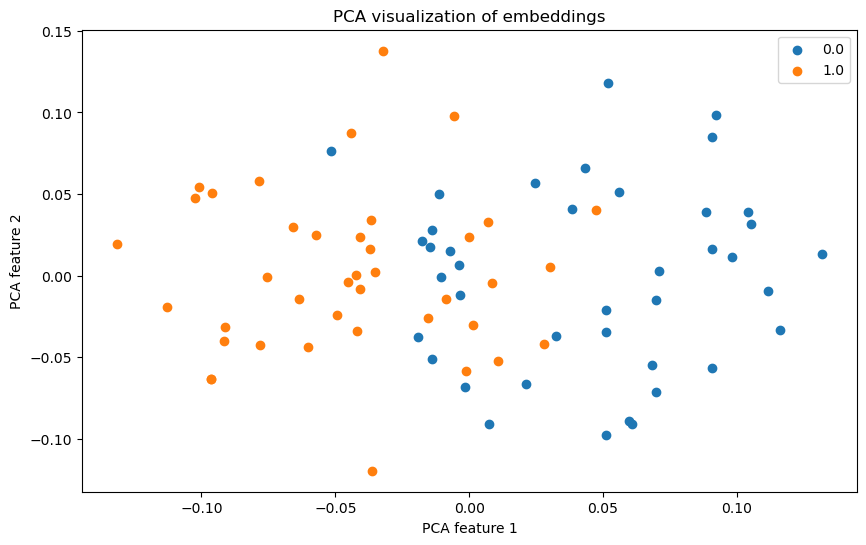

In [62]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

def visualize_embeddings_with_pca(embeddings, labels):
    """
    Visualize the embeddings using PCA.

    
    :param embeddings: A numpy array of embeddings.
    :param labels: The corresponding labels of the embeddings.
    """

     # Ensure labels is a 1D array
    labels = np.squeeze(labels)

    # Verify that the number of labels matches the number of embeddings
    assert len(labels) == len(embeddings), "The number of labels must match the number of embeddings"

    # Compute PCA
    pca = PCA(n_components=4,random_state=40)
    reduced_embeddings = pca.fit_transform(embeddings)

    # Plot
    plt.figure(figsize=(10, 6))
    unique_labels = np.unique(labels)
    for label in unique_labels:
        indices = labels == label
        plt.scatter(reduced_embeddings[indices, 0], reduced_embeddings[indices, 1], label=label)
    plt.legend()
    plt.title("PCA visualization of embeddings")
    plt.xlabel("PCA feature 1")
    plt.ylabel("PCA feature 2")
    plt.show()

# Example usage
# Assuming you have a list/array of labels corresponding to your images
labels = Y  # Your labels here
small_embeddings = concatenated_embeddings  # Adjust this based on your dataset size
small_labels = labels
#visualize_embeddings(small_embeddings, small_labels)
# Visualize
visualize_embeddings_with_pca(small_embeddings,small_labels)
#visualize_embeddings_with_pca(concatenated_embeddings, labels)


In [63]:
# Assuming `embeddings` and `labels` are your data
n_support = 5  # Number of examples per class for support set

support_embeddings = []
query_embeddings = []
support_labels = []
query_labels = []

for label in np.unique(labels):
    indices = np.where(labels == label)[0]
    np.random.shuffle(indices)
    
    support_indices = indices[:n_support]
    query_indices = indices[n_support:]

    support_embeddings.append(concatenated_embeddings[support_indices])
    query_embeddings.append(concatenated_embeddings[query_indices])
    support_labels.append(labels[support_indices])
    query_labels.append(labels[query_indices])

# Convert to numpy arrays
support_embeddings = np.vstack(support_embeddings)
query_embeddings = np.vstack(query_embeddings)
support_labels = np.concatenate(support_labels)
query_labels = np.concatenate(query_labels)

# Convert labels to 1D arrays
support_labels = np.concatenate(support_labels).flatten()
query_labels = np.concatenate(query_labels).flatten()
support_embeddings.shape



(10, 100)

In [64]:
import tensorflow as tf
from tensorflow.keras import regularizers
def shuffle_and_batch_tf(data, labels, batch_size):
    """
    Shuffle the data and labels and divide them into batches using TensorFlow operations.

    :param data: TensorFlow tensor of data (embeddings).
    :param labels: TensorFlow tensor of labels.
    :param batch_size: Size of each batch.
    :return: A list of batches, each batch containing data and labels.
    """
   

    # Shuffle data and labels in unison
    indices = tf.range(start=0, limit=tf.shape(data)[0], dtype=tf.int32)
    shuffled_indices = tf.random.shuffle(indices)

    shuffled_data = tf.gather(data, shuffled_indices)
    shuffled_labels = tf.gather(labels, shuffled_indices)

    # Calculate the number of batches
    num_batches = int(tf.math.ceil(tf.shape(data)[0] / batch_size).numpy())

    # Split data and labels into batches
    batched_data = [shuffled_data[i*batch_size:(i+1)*batch_size] for i in range(num_batches)]
    batched_labels = [shuffled_labels[i*batch_size:(i+1)*batch_size] for i in range(num_batches)]

    return list(zip(batched_data, batched_labels))


In [65]:
def create_model_hybrid(input_dim, output_dim, regularization_rate=0.01):
    regularizer = tf.keras.regularizers.l2(regularization_rate)
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(1024, activation='relu', input_shape=(input_dim,),
                              kernel_regularizer=regularizer),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=regularizer),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(100, activation='relu', kernel_regularizer=regularizer),
        tf.keras.layers.Dense(output_dim)
    ])
    return model

# Assuming each embedding is of size 100
hybrid = create_model_hybrid(input_dim=100, output_dim=100)


In [66]:

def create_embedding_model_for_prototy(embedding_size, input_shape):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.Dense(units=64, activation='relu', 
                              kernel_regularizer=regularizers.L1L2(l1=1e-2, l2=1e-3), 
                              bias_regularizer=regularizers.L2(1e-2),
                              activity_regularizer=regularizers.L2(1e-2)),
        tf.keras.layers.Dense(units=128, activation='relu', 
                              kernel_regularizer=regularizers.L1L2(l1=1e-2, l2=1e-3), 
                              bias_regularizer=regularizers.L2(1e-2),
                              activity_regularizer=regularizers.L2(1e-2)),
        tf.keras.layers.Dropout(0.01),
        tf.keras.layers.Dense(units=128, activation='relu', 
                              kernel_regularizer=regularizers.L1L2(l1=1e-2, l2=1e-3), 
                              bias_regularizer=regularizers.L2(1e-4),
                              activity_regularizer=regularizers.L2(1e-2)),
        tf.keras.layers.Dense(units=64, activation='relu', 
                              kernel_regularizer=regularizers.L1L2(l1=1e-2, l2=1e-3), 
                              bias_regularizer=regularizers.L2(1e-2),
                              activity_regularizer=regularizers.L2(1e-2)),
        tf.keras.layers.Dense(units=embedding_size, activation='sigmoid'),
    ])
    return model

hybrid = create_embedding_model_for_prototy(embedding_size =100 , input_shape=(100,))


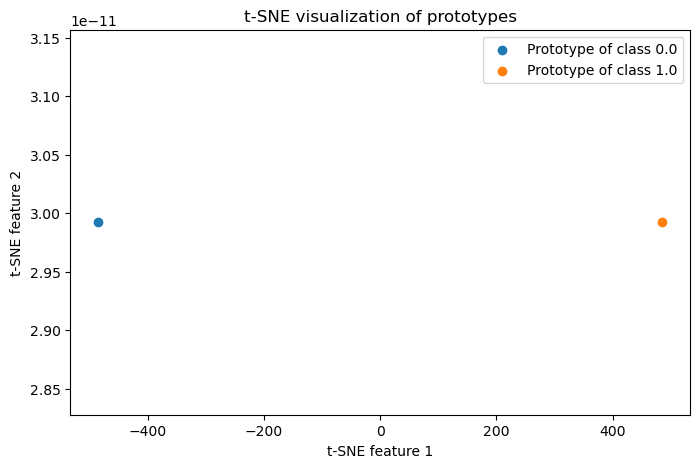

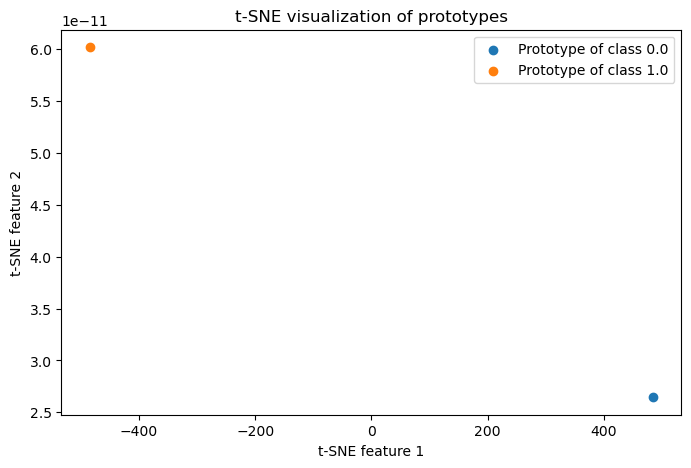

In [67]:
import tensorflow as tf
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

def compute_prototypes(embeddings, labels):
    labels = tf.reshape(labels, [-1])
    unique_labels, unique_idx = tf.unique(labels)
    prototypes = tf.TensorArray(dtype=tf.float32, size=tf.size(unique_labels), dynamic_size=False)

    for i in tf.range(tf.size(unique_labels)):
        label = unique_labels[i]
        label_embeddings = tf.boolean_mask(embeddings, tf.equal(labels, label))
        prototype = tf.reduce_mean(label_embeddings, axis=0)
        prototypes = prototypes.write(i, prototype)

    prototypes = prototypes.stack()
    return prototypes

# Example usage:
# Assuming `embeddings` is a 2D tensor of your embeddings and `labels` is a 1D tensor of your labels
# Compute the prototypes

# Assuming support_embeddings and query_embeddings are your two sets of embeddings,
# and support_labels and query_labels are the corresponding labels for each set.

def compute_and_visualize_prototypes(embeddings, labels):
    # Compute prototypes using the provided function
    prototypes = compute_prototypes(embeddings, labels)
    # Convert to numpy arrays for t-SNE
    prototypes_numpy = prototypes.numpy()
    labels_numpy = labels
    # Use t-SNE for dimensionality reduction
    num_prototypes = prototypes_numpy.shape[0]
    tsne_perplexity = min(30, num_prototypes - 1)  # Subtract 1 to ensure perplexity is less than num_prototypes
    tsne = TSNE(n_components=2, perplexity=tsne_perplexity, random_state=42)
    #tsne = TSNE(n_components=2, random_state=42)
    reduced_prototypes = tsne.fit_transform(prototypes_numpy)
    # Plotting
    plt.figure(figsize=(8, 5))
    for i, label in enumerate(np.unique(labels_numpy)):
        plt.scatter(reduced_prototypes[i, 0], reduced_prototypes[i, 1], label=f'Prototype of class {label}')
    plt.title('t-SNE visualization of prototypes')
    plt.xlabel('t-SNE feature 1')
    plt.ylabel('t-SNE feature 2')
    plt.legend()
    plt.show()

# You would call the function for each set of embeddings like this:
compute_and_visualize_prototypes(support_embeddings, support_labels)
compute_and_visualize_prototypes(query_embeddings, query_labels)



In [68]:
num_epochs=100
batch_size=1024


import tensorflow as tf


def compute_prototypes(embeddings, labels):
    """
    Compute class prototypes as the mean of embeddings for each class.

    :param embeddings: 2D TensorFlow tensor of embeddings.
    :param labels: 1D TensorFlow tensor of labels corresponding to the embeddings.
    :return: 2D TensorFlow tensor of class prototypes.
    """
    labels = tf.reshape(labels, [-1])
    unique_labels, unique_idx = tf.unique(labels)
    prototypes = tf.TensorArray(dtype=tf.float32, size=0, dynamic_size=True)

    for i in tf.range(tf.size(unique_labels)):
        label = unique_labels[i]
        label_embeddings = tf.boolean_mask(embeddings, tf.equal(labels, label))
        prototype = tf.reduce_mean(label_embeddings, axis=0)
        prototypes = prototypes.write(i, prototype)

    prototypes = prototypes.stack()
    return prototypes


def prototypical_loss2(prototypes, query_embeddings, query_labels):
    """
    Compute the prototypical loss using TensorFlow.

    :param prototypes: 2D TensorFlow tensor of class prototypes.
    :param query_embeddings: 2D TensorFlow tensor of query embeddings.
    :param query_labels: 1D TensorFlow tensor of labels for the query embeddings.
    :return: The prototypical loss value.
    """
    # Calculate squared Euclidean distance between each query embedding and each prototype
    # Expanding dimensions to facilitate broadcasting
    distances = tf.sqrt(tf.reduce_sum(tf.square(tf.expand_dims(query_embeddings, 1) - tf.expand_dims(prototypes, 0)), axis=2))

    # Compute log probabilities using log_softmax on negative distances
    log_probabilities = tf.nn.log_softmax(-distances, axis=1)

    # Flatten query_labels if it's not already 1D and cast to int32
    query_labels = tf.cast(tf.reshape(query_labels, [-1]), tf.int32)

    indices = tf.stack((tf.range(tf.shape(query_labels)[0]), query_labels), axis=1)

    # Gather the log probabilities of the true class for each query point
    relevant_log_probs = tf.gather_nd(log_probabilities, indices)

    # Compute the mean negative log probability (loss)
    loss = -tf.reduce_mean(relevant_log_probs)
    return loss
def prototypical_loss(input, prototypes, target):
    # Ensure target is of type int32
    target_int = tf.cast(target, tf.int32)

    # Compute the distance between the input and each prototype
    distances = tf.norm(tf.expand_dims(input, axis=1) - prototypes, axis=-1)
    
    # Compute the negative log-probability of the correct class
    log_probs = tf.nn.log_softmax(-distances, axis=-1)
    loss = -tf.reduce_mean(tf.boolean_mask(log_probs, tf.one_hot(target_int, depth=2)))
    
    return loss
#print(base_network.trainable_variables)
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)



In [69]:
import tensorflow as tf

# Assuming `hybrid` is your model and you have defined support_embeddings, query_embeddings, support_labels, query_labels

# Learning rate scheduler
#import tensorflow as tf
#import numpy as np
import random

# Set the random seed for reproducibility
seed = 42
tf.random.set_seed(seed)
np.random.seed(seed)
random.seed(seed)

initial_learning_rate = 0.001
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate,
    decay_steps=10000,
    decay_rate=0.9998,
    staircase=True)

optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

# Weights initialization with a seed
initializer = tf.keras.initializers.HeNormal(seed=seed)

# Your model summary
print(hybrid.summary())


# Training loop
#for epoch in range(num_epochs):
    # ... your existing code for batching ...
#    train_support_batches = shuffle_and_batch_tf(tf.convert_to_tensor(support_embeddings), tf.convert_to_tensor(support_labels), batch_size)
#    train_query_batches = shuffle_and_batch_tf(tf.convert_to_tensor(query_embeddings), tf.convert_to_tensor(query_labels), batch_size)
    # Training phase
#    for (batch_support_embeddings, batch_support_labels), (batch_query_embeddings, batch_query_labels) in zip(train_support_batches, train_query_batches):
 #       with tf.GradientTape() as tape:
#            support_embeddings = hybrid(batch_support_embeddings, training=True) # Make sure to set training to True
#            query_embeddings = hybrid(batch_query_embeddings, training=True)
#            prototypes = compute_prototypes(support_embeddings, batch_support_labels)
#            loss = prototypical_loss(query_embeddings,prototypes, batch_query_labels )

 #       gradients = tape.gradient(loss, hybrid.trainable_variables)
 #       optimizer.apply_gradients(zip(gradients, hybrid.trainable_variables))
    
    # Print the loss at the end of each epoch
 #   print(f'Epoch {epoch}: Training Loss: {loss.numpy()}')


Model: "sequential_8"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_28 (Dense)            (None, 64)                6464      
                                                                 
 dense_29 (Dense)            (None, 128)               8320      
                                                                 
 dropout_8 (Dropout)         (None, 128)               0         
                                                                 
 dense_30 (Dense)            (None, 128)               16512     
                                                                 
 dense_31 (Dense)            (None, 64)                8256      
                                                                 
 dense_32 (Dense)            (None, 100)               6500      
                                                                 
Total params: 46,052
Trainable params: 46,052
Non-trai

Epoch 0: Training Loss: 0.6933760643005371, Training Accuracy: 0.3285714387893677
Epoch 1: Training Loss: 0.693035900592804, Training Accuracy: 0.48571428656578064
Epoch 2: Training Loss: 0.6926154494285583, Training Accuracy: 0.6285714507102966
Epoch 3: Training Loss: 0.6926419734954834, Training Accuracy: 0.6285714507102966
Epoch 4: Training Loss: 0.6922308802604675, Training Accuracy: 0.6142857074737549
Epoch 5: Training Loss: 0.69194096326828, Training Accuracy: 0.6571428775787354
Epoch 6: Training Loss: 0.6917669773101807, Training Accuracy: 0.6285714507102966
Epoch 7: Training Loss: 0.6911605000495911, Training Accuracy: 0.7285714149475098
Epoch 8: Training Loss: 0.6908385157585144, Training Accuracy: 0.7428571581840515
Epoch 9: Training Loss: 0.6902269124984741, Training Accuracy: 0.7857142686843872
Epoch 10: Training Loss: 0.690005898475647, Training Accuracy: 0.7714285850524902
Epoch 11: Training Loss: 0.6890949606895447, Training Accuracy: 0.7571428418159485
Epoch 12: Trainin

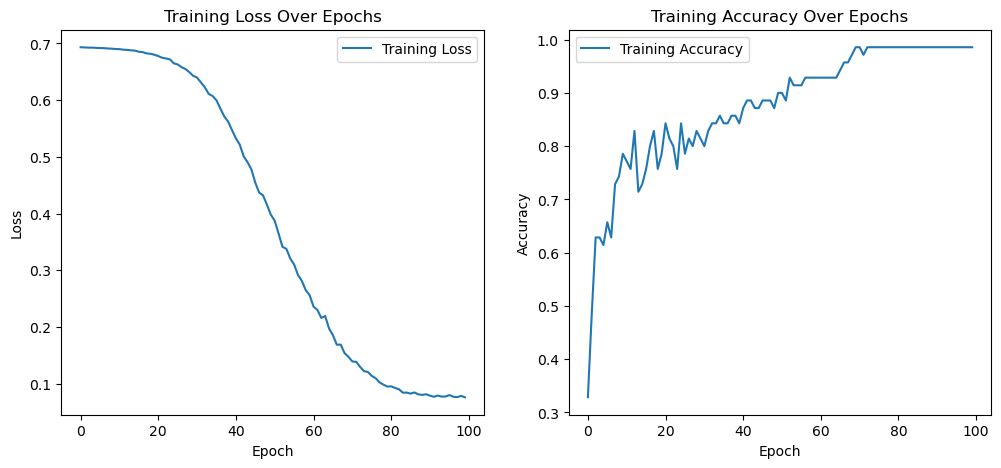

In [70]:
import matplotlib.pyplot as plt

# Initialize lists to store loss and accuracy values
epoch_losses = []
epoch_accuracies = []

# Training loop
train_support_batches = shuffle_and_batch_tf(tf.convert_to_tensor(support_embeddings), tf.convert_to_tensor(support_labels), batch_size)
train_query_batches = shuffle_and_batch_tf(tf.convert_to_tensor(query_embeddings), tf.convert_to_tensor(query_labels), batch_size)
for epoch in range(num_epochs):
    total_loss = 0
    correct_predictions = 0
    total_predictions = 0
    
    for (batch_support_embeddings, batch_support_labels), (batch_query_embeddings, batch_query_labels) in zip(train_support_batches, train_query_batches):
        with tf.GradientTape() as tape:
            support_embeddings = hybrid(batch_support_embeddings, training=True) # Make sure to set training to True
            query_embeddings = hybrid(batch_query_embeddings, training=True)
            prototypes = compute_prototypes(support_embeddings, batch_support_labels)
            loss = prototypical_loss(query_embeddings, prototypes, batch_query_labels)

        gradients = tape.gradient(loss, hybrid.trainable_variables)
        optimizer.apply_gradients(zip(gradients, hybrid.trainable_variables))
        
        total_loss += loss.numpy()
        batch_query_labels_int64 = tf.cast(batch_query_labels, tf.int64)
        # Calculate accuracy
        predicted_labels = tf.argmax(-tf.norm(tf.expand_dims(query_embeddings, axis=1) - prototypes, axis=-1), axis=1)
        correct_predictions += tf.reduce_sum(tf.cast(tf.equal(predicted_labels, batch_query_labels_int64), tf.float32))
        total_predictions += len(batch_query_labels)

    # Calculate epoch loss and accuracy
    epoch_loss = total_loss / len(train_support_batches)
    epoch_accuracy = correct_predictions / total_predictions

    epoch_losses.append(epoch_loss)
    epoch_accuracies.append(epoch_accuracy)

    # Print the loss and accuracy at the end of each epoch
    print(f'Epoch {epoch}: Training Loss: {epoch_loss}, Training Accuracy: {epoch_accuracy}')

# Plotting the training loss and accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epoch_losses, label='Training Loss')
plt.title('Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epoch_accuracies, label='Training Accuracy')
plt.title('Training Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()


Testing the model on unseen Dataset

In [71]:
normal_folder_path_test = 'C:\\Users\\SS IT\\Desktop\\Toward Ransomware Detection Using Few-shot learning\\RanSapDatasetand_Image\\Images\\normal test'
attack_folder_path_test = 'C:\\Users\\SS IT\\Desktop\\Toward Ransomware Detection Using Few-shot learning\\RanSapDatasetand_Image\\Images\\Ransom test'
total_sample_size_test =   30# sumation of both benign and attack dataset

test_X,test_Y=get_data(normal_folder_path_test,attack_folder_path_test,total_sample_size_test)
#len(test_X[:,1])
test_concatenated_embeddings, embeddings_a, embeddings_b = compute_concatenated_embeddings(base_network,test_X[:, 0], test_X[:, 1])
#len(test_concatenated_embeddings)
len(test_Y)

1/1 [==============================] - 0s 47ms/step


30

In [72]:
# Assuming `embeddings` and `labels` are your data
test_n_support = 10 # Number of examples per class for support set

test_support_embeddings = []
test_query_embeddings = []
test_support_labels = []
test_query_labels = []

for label in np.unique(test_Y):
    indices = np.where(test_Y == label)[0]
    np.random.shuffle(indices)
    
    support_indices = indices[:test_n_support]
    query_indices = indices[test_n_support:]

    test_support_embeddings.append(test_concatenated_embeddings[support_indices])
    test_query_embeddings.append(test_concatenated_embeddings[query_indices])
    test_support_labels.append(test_Y[support_indices])
    test_query_labels.append(test_Y[query_indices])
    #print(test_query_labels)
# Convert to numpy arrays
test_support_embeddings = np.vstack(test_support_embeddings)
test_query_embeddings = np.vstack(test_query_embeddings)
test_support_labels = np.concatenate(test_support_labels)
test_query_labels = np.concatenate(test_query_labels)

# Convert labels to 1D arrays
test_support_labels = np.concatenate(test_support_labels).flatten()
#test_query_labels = np.concatenate(test_query_labels).flatten()
test_query_labels = test_query_labels.flatten()



# ... your existing code for preparing test data ...

# Debugging: Check shapes of the arrays
print("Test support embeddings shape:", test_support_embeddings.shape)
print("Test query embeddings shape:", test_query_embeddings.shape)
print("Test support labels shape:", test_support_labels.shape)
print("Test query labels shape:", test_query_labels.shape)

# Assuming shuffle_and_batch_tf is correctly implemented
test_support_batches = shuffle_and_batch_tf(tf.convert_to_tensor(test_support_embeddings), tf.convert_to_tensor(test_support_labels), batch_size)
test_query_batches = shuffle_and_batch_tf(tf.convert_to_tensor(test_query_embeddings), tf.convert_to_tensor(test_query_labels), batch_size)

# Debugging: Check the length and content of the batches
print("Number of test support batches:", len(test_support_batches))
print("Number of test query batches:", len(test_query_batches))


Test support embeddings shape: (20, 100)
Test query embeddings shape: (10, 100)
Test support labels shape: (20,)
Test query labels shape: (10,)
Number of test support batches: 1
Number of test query batches: 1


Test Loss: 1.3430330753326416, Test Accuracy: 0.699999988079071
Confusion Matrix:
 [[3 2]
 [1 4]]
F1 Score: 0.7272727272727272
Precision: 0.6666666666666666
Recall: 0.8
ROC AUC: 0.7000000000000001


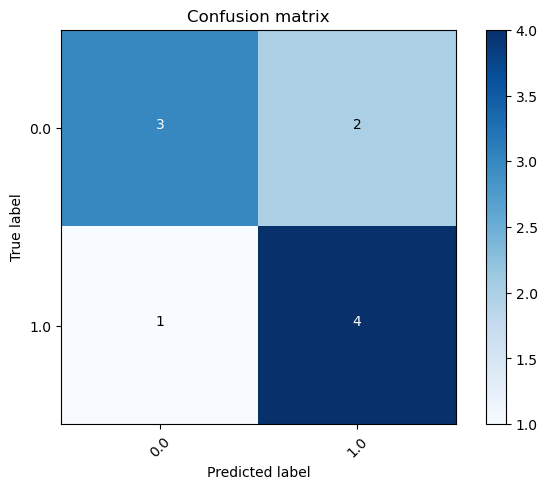

In [73]:
import numpy as np
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score, accuracy_score, roc_auc_score
import matplotlib.pyplot as plt
import itertools

# Function to plot confusion matrix
def plot_confusion_matrix(cm, classes, title='Confusion matrix', cmap=plt.cm.Blues):
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

# Initialize lists to collect labels
all_true_labels = []
all_predicted_labels = []

total_test_loss = 0
correct_test_predictions = 0
total_test_predictions = 0

for (batch_support_embeddings, batch_support_labels), (batch_query_embeddings, batch_query_labels) in zip(test_support_batches, test_query_batches):
    # Forward pass
    support_embeddings = hybrid(batch_support_embeddings, training=False)
    query_embeddings = hybrid(batch_query_embeddings, training=False)
    prototypes = compute_prototypes(support_embeddings, batch_support_labels)
    test_loss = prototypical_loss(query_embeddings, prototypes, batch_query_labels)

    total_test_loss += test_loss.numpy()

    # Calculate accuracy
    predicted_labels = tf.argmax(-tf.norm(tf.expand_dims(query_embeddings, axis=1) - prototypes, axis=-1), axis=1)
    correct_test_predictions += tf.reduce_sum(tf.cast(tf.equal(predicted_labels, tf.cast(batch_query_labels, tf.int64)), tf.float32))
    total_test_predictions += len(batch_query_labels)

    # Collect true and predicted labels for metrics calculation
    all_true_labels.extend(batch_query_labels.numpy())
    all_predicted_labels.extend(predicted_labels.numpy())

# Convert collected labels to numpy arrays
all_true_labels = np.array(all_true_labels)
all_predicted_labels = np.array(all_predicted_labels)

# Calculate overall test metrics
avg_test_loss = total_test_loss / len(test_support_batches)
test_accuracy = correct_test_predictions / total_test_predictions
conf_matrix = confusion_matrix(all_true_labels, all_predicted_labels)
f1 = f1_score(all_true_labels, all_predicted_labels, average='binary')
precision = precision_score(all_true_labels, all_predicted_labels, average='binary')
recall = recall_score(all_true_labels, all_predicted_labels, average='binary')
roc_auc = roc_auc_score(all_true_labels, all_predicted_labels)

# Print metrics
print(f'Test Loss: {avg_test_loss}, Test Accuracy: {test_accuracy}')
print("Confusion Matrix:\n", conf_matrix)
print("F1 Score:", f1)
print("Precision:", precision)
print("Recall:", recall)
print("ROC AUC:", roc_auc)

# Plot Confusion Matrix
plt.figure()
plot_confusion_matrix(conf_matrix, classes=np.unique(all_true_labels))
plt.show()


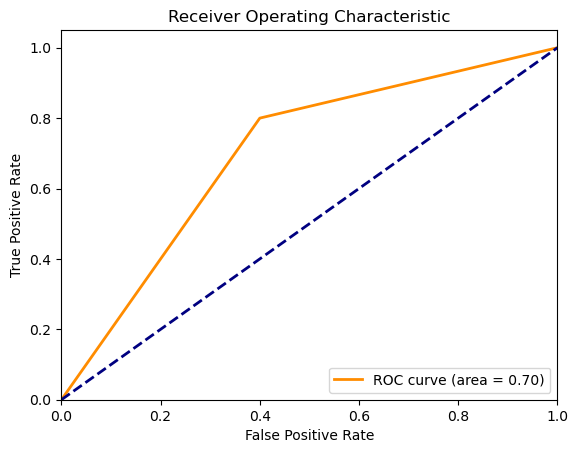

In [74]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Calculate False Positive Rate and True Positive Rate for ROC
fpr, tpr, thresholds = roc_curve(all_true_labels, all_predicted_labels)
roc_auc = auc(fpr, tpr)

# Plotting the ROC Curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()
